In [ ]:
!pip install simpy networkx igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 34.8 MB/s eta 0:00:00


# Symulacja i Analiza Sieci Złożonych
### Prezentacja pakietów: SimPy, NetworkX oraz igraph

Niniejszy notebook stanowi pigułkę technologiczną wprowadzającą do narzędzi wykorzystanych w głównym projekcie symulatora kryzysowego. Pokazuje on integrację trzech filarów nowoczesnej analizy systemów:
1. **Modelowania procesowego w czasie** (SimPy)
2. **Architektury i wizualizacji struktur** (NetworkX)
3. **Masowej analityki grafowej** (igraph)

In [ ]:
import networkx as nx
import random
import simpy
import igraph as ig
import matplotlib.pyplot as plt

## 1. SimPy | Zarządzanie Czasem i Rywalizacja o Zasoby
Modelowanie dynamiczne systemów kolejkowych przy użyciu paradygmatu symulacji zdarzeń dyskretnych (DES).

* **Mechanizm `yield env.timeout()`**: Wstrzymuje proces na określony czas, symulując np. czas trwania operacji.
* **Obiekt `simpy.Resource`**: Reprezentuje zasób o ograniczonej pojemności. Wymusza powstawanie kolejek (wąskich gardeł), gdy zapotrzebowanie przekracza przepustowość.

> **W projekcie głównym:** Ten mechanizm odpowiada za uziemianie samolotów na płytach lotnisk oraz generowanie zatorów w przypadku blokady portu docelowego.

In [ ]:
def prosty_proces(env, nazwa, zasob):
    print(f"[{env.now:02d}] {nazwa}: Przybycie i żądanie zasobu.")

    with zasob.request() as req:
        yield req  # Oczekiwanie w kolejce, jeśli zasób jest zajęty
        print(f"[{env.now:02d}] {nazwa}: Uzyskano dostęp. Rozpoczęcie pracy.")

        yield env.timeout(random.randint(3, 7))  # Upływ czasu w symulacji
        print(f"[{env.now:02d}] {nazwa}: Zakończono proces.")


#Konfiguracja środowiska i uruchomienie
env = simpy.Environment()
wspolny_zasob = simpy.Resource(
    env, capacity=1
)  # Tylko 1 proces na raz może korzystać

# Dodajemy dwa procesy do środowiska
env.process(prosty_proces(env, "Proces A", wspolny_zasob))
env.process(prosty_proces(env, "Proces B", wspolny_zasob))

env.run()

[00] Proces A: Przybycie i żądanie zasobu.
[00] Proces B: Przybycie i żądanie zasobu.
[00] Proces A: Uzyskano dostęp. Rozpoczęcie pracy.
[06] Proces A: Zakończono proces.
[06] Proces B: Uzyskano dostęp. Rozpoczęcie pracy.
[11] Proces B: Zakończono proces.


## 2. NetworkX | Topologia Sieci, Algorytmy i Wizualizacja
Definiowanie struktury grafowej systemu oraz wyznaczanie optymalnych ścieżek przepływu w oparciu o wagi krawędzi.

* **Struktura Grafu**: Reprezentacja punktów sieciowych (węzły) oraz relacji i dystansów między nimi (krawędzie z wagami).
* **Funkcja `nx.shortest_path`**: Implementacja algorytmów wyszukiwania najkrótszych ścieżek (np. Dijkstry) z uwzględnieniem kosztu przejścia.
* **Wizualizacja**: Szybkie, natywne mapowanie struktury grafu na czytelny wykres statyczny.

> **W projekcie głównym:** Odpowiada za pełną mapę połączeń lotniczych w Polsce oraz za logikę wyszukiwania najbliższych lotnisk zapasowych podczas przekierowań.

=== ANALIZA NETWORKX ===
Wszystkie węzły w sieci: ['A', 'B', 'C', 'D']
Najkrótsza ścieżka z B do D (wg wag): B -> C -> A -> D

=== GENEROWANIE WYKRESU ===


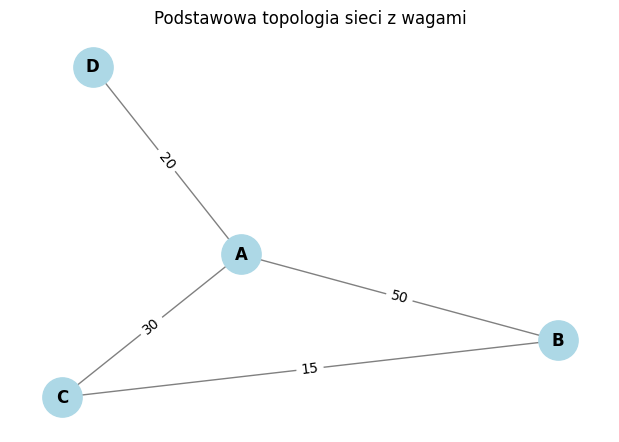

In [ ]:

#Tworzenie pustego grafu i dodawanie krawędzi z wagami (odległościami)
G = nx.Graph()
G.add_edge("A", "B", weight=50)
G.add_edge("B", "C", weight=15)
G.add_edge("A", "C", weight=30)
G.add_edge("A", "D", weight=20)

#Analiza sieciowa
print("Wszystkie węzły w sieci:", list(G.nodes))
sciezka = nx.shortest_path(G, source="B", target="D", weight="weight")
print(f"Najkrótsza ścieżka z B do D (wg wag): {' -> '.join(sciezka)}")


plt.figure(figsize=(6, 4))

# Określenie pozycji węzłów na wykresie (układ wiosenny/siłowy)
pos = nx.spring_layout(G, seed=42)

# Rysowanie węzłów i krawędzi
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=800,
    font_weight="bold",
    edge_color="gray",
)

# Pobranie wag krawędzi i nałożenie ich jako etykiety na linie
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Podstawowa topologia sieci z wagami")
plt.show()

## 3. igraph | Skalowanie Obliczeń i Metryki Strukturalne
Wydajna, niskopoziomowa alternatywa dla NetworkX, dedykowana do wyznaczania zaawansowanych miar sieciowych w systemach masowych.

* **Optymalizacja w C**: Architektura biblioteki pozwala na błyskawiczną analizę sieci o ogromnych rozmiarach.
* **Wagowa Miara Pośrednictwa (Weighted Betweenness Centrality)**: Wskaźnik określający, jak często dany węzeł leży na najkrótszych ścieżkach między innymi punktami sieci z uwzględnieniem kosztu (wagi) krawędzi.

> **W projekcie głównym:** Pozwala na identyfikację strategicznych punktów sieci (węzłów krytycznych). Wprowadzenie wag (odległości między lotniskami) pozwala przewidzieć zachowanie systemu w warunkach kryzysowych. Wysoki wskaźnik *Wagowego Betweenness* wskazuje, które lotniska staną się najbardziej obciążone i podatne na zatory (kumulację samolotów na płycie), gdy sąsiednie porty zostaną zamknięte, a ruch zacznie być dynamicznie przekierowywany na trasy alternatywne.

In [ ]:
# Tworzenie grafu w igraph z uwzględnieniem wag krawędzi
krawedzie_z_wagami = [
    ("A", "B", 50),
    ("B", "C", 15),
    ("A", "C", 30),
    ("A", "D", 20),
]

G_ig = ig.Graph.TupleList(krawedzie_z_wagami, directed=False, weights=True)

# Wyznaczenie najkrótszej ścieżki na podstawie wag (z B do D)
sciezka_indeksy = G_ig.get_shortest_paths("B", to="D", weights="weight")[0]

# Mapowanie indeksów węzłów z powrotem na ich nazwy tekstowe
sciezka_nazwy = [G_ig.vs[idx]["name"] for idx in sciezka_indeksy]
print(f"Najkrótsza ścieżka z B do D (wg wag): {' -> '.join(sciezka_nazwy)}")

print("-" * 50)

# Metryki strukturalne dla tej konkretnej topologii
print("Stopnie węzłów (liczba sąsiadów):")
for v in G_ig.vs:
    print(f" Węzeł {v['name']}: stopień = {v.degree()}")

# Wyznaczenie Betweenness Centrality (miary pośrednictwa)
betweenness = G_ig.betweenness()
betweenness_weighted = G_ig.betweenness(weights="weight")

print("\nMiara pośrednictwa (Betweenness):", dict(zip(G_ig.vs["name"], betweenness)))
print("\nMiara pośrednictwa (Betweenness) z uwzględnieniem wag:", dict(zip(G_ig.vs["name"], betweenness_weighted)))

Najkrótsza ścieżka z B do D (wg wag): B -> C -> A -> D
--------------------------------------------------
Stopnie węzłów (liczba sąsiadów):
 Węzeł A: stopień = 3
 Węzeł B: stopień = 2
 Węzeł C: stopień = 2
 Węzeł D: stopień = 1

Miara pośrednictwa (Betweenness): {'A': 2.0, 'B': 0.0, 'C': 0.0, 'D': 0.0}

Miara pośrednictwa (Betweenness) z uwzględnieniem wag: {'A': 2.0, 'B': 0.0, 'C': 2.0, 'D': 0.0}
